### Step 1: Import crucial libraries ###

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM, Dense, Dropout


### Step 2: Import datasets and show data ###

In [3]:
#-- Import file traffic master dataset. --#
df_traffic_master = pd.read_csv("../Processed/Full_Traffic_With_Validity.csv")
# Display basic info and the first 5 rows
print("--- [DATASET 1] Traffic Master Data ---")
print(f"Shape: {df_traffic_master.shape} (Rows, Columns)")
display(df_traffic_master.head())
# Quick check on the validity column we added
print("\nQuick check on 'Valid_Days' distribution:")
print(df_traffic_master['Valid_Days'].value_counts())

--- [DATASET 1] Traffic Master Data ---
Shape: (4192, 108) (Rows, Columns)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V88,V89,V90,V91,V92,V93,V94,V95,Daily_Total,Valid_Days
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/1/2006,...,97,66,81,50,59,47,29,34,13780,31
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/2/2006,...,107,114,80,60,62,48,44,26,17362,31
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/3/2006,...,114,86,93,90,73,57,29,40,18870,31
3,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/4/2006,...,132,101,113,90,78,66,52,44,18700,31
4,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/5/2006,...,116,113,99,91,61,55,49,36,19533,31



Quick check on 'Valid_Days' distribution:
Valid_Days
31    3337
26     390
29     230
30     173
62      62
Name: count, dtype: int64


In [4]:
#-- Import file station efficiency. --#
df_stations = pd.read_csv("../Processed/efficiency_stations.csv")

# Display basic info and the first 5 rows
print("--- [DATASET 2] Station Efficiency Data ---")
print(f"Shape: {df_stations.shape} (Rows, Columns)")
display(df_stations.head())

# Check for unique station identifiers
print("\nUnique stations in this file:", df_stations['tfm_id'].nunique() if 'tfm_id' in df_stations.columns else "Column 'tfm_id' not found")

--- [DATASET 2] Station Efficiency Data ---
Shape: (3504, 24) (Rows, Columns)


,x,y,fid,objectid,tfm_id,tfm_desc,tfm_typ_de,movement_t,site_desc,road_nbr,...,time_categ,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_name,road_avg_aadt,efficiency_index,vs_average_pct
0,144.560081,-37.968598,45122,45324,42013,PRINCES FWY WB ON-RAMP FROM SOUTH RD,MIDBLOCK,On Ramp,PRINCES FWY ON-RAMP FROM SOUTH RD,7024,...,Greater than 10 Years,18,1998,40,0,0.21,160 SOUTH ROADB 2500F,40.0,1.00,0.0
1,145.088615,-37.881431,55947,55189,52075,MONASH FWY OUTBOUND OFFRAMP TO WARRIGAL RD,INTERSECTION,Off Ramp,SVO_Map_LTD:838||SITE DESC: MONASH FWY OUTBOUN...,7138,...,Between 5 and 10 Years,10,2006,13000,0,0.00,2000F 2070B,5350.0,2.43,143.0
2,145.090058,-37.882231,38735,38966,36894,S.E.ARTERIAL OFF RAMP NW OF WARRIGAL RD,INTERSECTION,Off Ramp,S.E.ARTERIAL SEBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,19,1997,8400,640,0.08,2000F 2070B,5350.0,1.57,57.0
3,145.088615,-37.881431,23193,23092,54241,S.E.ARTERIAL ON RAMP NW OF WARRIGAL RD,INTERSECTION,On Ramp,S.E.ARTERIAL NWBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,0,0,0,0,0.00,2000F 2070B,5350.0,0.00,-100.0
4,145.222981,-37.957762,6407,6604,9101,MONASH FWY OFF RAMP SEBD TO STUD RD,INTERSECTION,Off Ramp,MONASH FWY OFF RAMP STO STUD RD,7144,...,Between 5 and 10 Years,9,2007,8600,830,0.10,2000F 2090B,5625.0,1.53,53.0



Unique stations in this file: 3504


In [5]:
#-- Show data in bad records list. --#
# Load the dataset
df_bad_list = pd.read_csv('../Processed/Bad_Records_List.csv')

# Display basic info and the first few rows
print("--- [DATASET 3] Bad Records List (To be removed) ---")
print(f"Shape: {df_bad_list.shape} (Rows, Columns)")
display(df_bad_list.head(10))

# Quick check: How many unique bad sites are there?
bad_sites_count = df_bad_list['Site_ID'].nunique()
print(f"\nTotal unique bad sites identified: {bad_sites_count}")

# Show some reasons why they are bad (if 'Issue' column exists)
if 'Issue' in df_bad_list.columns:
    print("\nCommon issues found:")
    print(df_bad_list['Issue'].value_counts())

--- [DATASET 3] Bad Records List (To be removed) ---
Shape: (14, 3) (Rows, Columns)


,Site_ID,Issue,Source_File
0,970,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
1,2000,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
2,2820,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
3,3001,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
4,3002,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
5,3127,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
6,3682,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
7,3685,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
8,4057,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
9,4262,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv



Total unique bad sites identified: 14

Common issues found:
Issue
Very poor data / Removed on selected days    14
Name: count, dtype: int64


### Step 3: Data Cleaning and Pre-processing ###

In [6]:
#-- Clean bad data in file efficiency stations. --#
#-- Load dataset --#
df_efficiency_stations = pd.read_csv("../Processed/efficiency_stations.csv")
df_bad_list = pd.read_csv('../Processed/Bad_Records_List.csv')

#-- Take list of bad site IDs --#
bad_ids = df_bad_list['Site_ID'].unique()

#-- Record the number of rows before cleaning for reporting. --#
rows_before = len(df_efficiency_stations)

#-- Filter out rows where 'tfm_id' is present in the blacklist. --#
df_efficiency_cleaned = df_efficiency_stations[~df_efficiency_stations['tfm_id'].isin(bad_ids)].copy()

#-- Calculate how many rows were removed. --#
rows_after = len(df_efficiency_cleaned)
rows_deleted = rows_before - rows_after

#-- Export the cleaned data to a new CSV file. --#
output_file = '../Processed/efficiency_stations_cleaned.csv'
df_efficiency_cleaned.to_csv(output_file, index=False)

# -- Final Report -- #
print(f"--- EFFICIENCY DATA CLEANING REPORT ---")
print(f"Rows before cleaning: {rows_before}")
print(f"Rows deleted (blacklisted): {rows_deleted}")
print(f"Rows remaining: {rows_after}")
print(f"Cleaned file saved as: {output_file}")

#-- Display the first few rows of the cleaned dataset. --#
display(df_efficiency_cleaned.head())


--- EFFICIENCY DATA CLEANING REPORT ---
Rows before cleaning: 3504
Rows deleted (blacklisted): 1
Rows remaining: 3503
Cleaned file saved as: ../Processed/efficiency_stations_cleaned.csv


,x,y,fid,objectid,tfm_id,tfm_desc,tfm_typ_de,movement_t,site_desc,road_nbr,...,time_categ,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_name,road_avg_aadt,efficiency_index,vs_average_pct
0,144.560081,-37.968598,45122,45324,42013,PRINCES FWY WB ON-RAMP FROM SOUTH RD,MIDBLOCK,On Ramp,PRINCES FWY ON-RAMP FROM SOUTH RD,7024,...,Greater than 10 Years,18,1998,40,0,0.21,160 SOUTH ROADB 2500F,40.0,1.00,0.0
1,145.088615,-37.881431,55947,55189,52075,MONASH FWY OUTBOUND OFFRAMP TO WARRIGAL RD,INTERSECTION,Off Ramp,SVO_Map_LTD:838||SITE DESC: MONASH FWY OUTBOUN...,7138,...,Between 5 and 10 Years,10,2006,13000,0,0.00,2000F 2070B,5350.0,2.43,143.0
2,145.090058,-37.882231,38735,38966,36894,S.E.ARTERIAL OFF RAMP NW OF WARRIGAL RD,INTERSECTION,Off Ramp,S.E.ARTERIAL SEBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,19,1997,8400,640,0.08,2000F 2070B,5350.0,1.57,57.0
3,145.088615,-37.881431,23193,23092,54241,S.E.ARTERIAL ON RAMP NW OF WARRIGAL RD,INTERSECTION,On Ramp,S.E.ARTERIAL NWBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,0,0,0,0,0.00,2000F 2070B,5350.0,0.00,-100.0
4,145.222981,-37.957762,6407,6604,9101,MONASH FWY OFF RAMP SEBD TO STUD RD,INTERSECTION,Off Ramp,MONASH FWY OFF RAMP STO STUD RD,7144,...,Between 5 and 10 Years,9,2007,8600,830,0.10,2000F 2090B,5625.0,1.53,53.0


In [7]:
#-- Processed the Fill_Traffic_With-Validity.csv. --#

#-- Load the traffic dataset and the blacklist. --#
df_traffic_full = pd.read_csv('../Processed/Full_Traffic_With_Validity.csv')

#-- Extract the bad IDs. --#
bad_ids = df_bad_list['Site_ID'].unique()

#-- Record statistics before cleaning --#
rows_before_traffic = len(df_traffic_full)
sites_before_traffic = df_traffic_full['SCATS Number'].nunique()

#-- Filter out rows where 'SCATS Number' matches any ID in the blacklist. --#
df_traffic_cleaned = df_traffic_full[~df_traffic_full['SCATS Number'].isin(bad_ids)].copy()

#-- Calculate the impact of cleaning. --#
rows_after_traffic = len(df_traffic_cleaned)
rows_deleted_traffic = rows_before_traffic - rows_after_traffic
sites_remaining_traffic = df_traffic_cleaned['SCATS Number'].nunique()

#-- Export the high-quality traffic data. --#
output_traffic_file = '../Processed/Full_Traffic_With_Validity_Cleaned.csv'
df_traffic_cleaned.to_csv(output_traffic_file, index=False)

# -- Execution Report -- #
print(f"--- TRAFFIC DATA CLEANING REPORT ---")
print(f"Rows before cleaning: {rows_before_traffic}")
print(f"Unique sites before: {sites_before_traffic}")
print(f"Rows deleted (blacklisted): {rows_deleted_traffic}")
print(f"Unique sites remaining: {sites_remaining_traffic}")
print(f"Cleaned traffic file saved as: {output_traffic_file}")

# Preview the cleaned data
display(df_traffic_cleaned.head())

--- TRAFFIC DATA CLEANING REPORT ---
Rows before cleaning: 4192
Unique sites before: 40
Rows deleted (blacklisted): 1309
Unique sites remaining: 26
Cleaned traffic file saved as: ../Processed/Full_Traffic_With_Validity_Cleaned.csv


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V88,V89,V90,V91,V92,V93,V94,V95,Daily_Total,Valid_Days
237,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/1/2006,...,34,28,28,14,14,15,12,5,4820,31
238,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/2/2006,...,32,25,21,22,17,7,8,7,6907,31
239,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/3/2006,...,40,33,32,46,11,11,11,7,7347,31
240,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/4/2006,...,40,26,34,24,25,15,8,8,7282,31
241,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/5/2006,...,38,47,31,26,22,15,14,9,7608,31


### Step 4: EDA ###

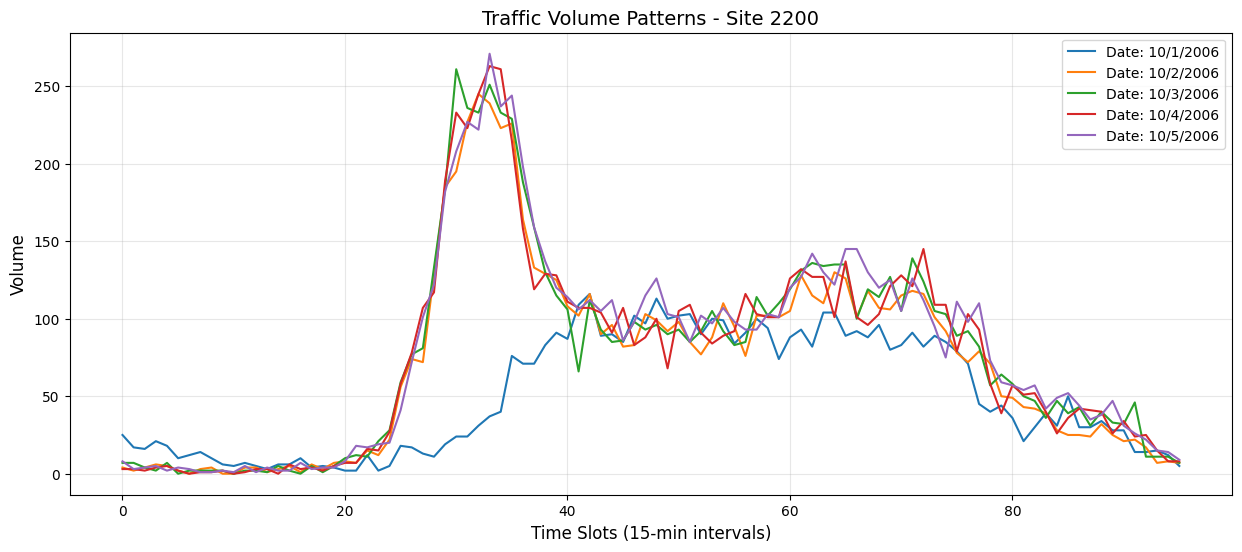

In [8]:
#-- Visualize 24-Hour traffic Pattern. --#
#-- Select sample data --#
sample_site_id = df_traffic_cleaned['SCATS Number'].iloc[0]
df_sample_plot = df_traffic_cleaned[df_traffic_cleaned['SCATS Number'] == sample_site_id]
v_columns = [f'V{i:02d}' for i in range(96)]

plt.figure(figsize=(15, 6))
#-- Plot first 5 days of data. --#
for index, row in df_sample_plot.head(5).iterrows():
    plt.plot(row[v_columns].values, label=f"Date: {row['Date']}")

plt.title(f"Traffic Volume Patterns - Site {sample_site_id}", fontsize=14)
plt.xlabel("Time Slots (15-min intervals)", fontsize=12)
plt.ylabel("Volume", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Save and show
plt.savefig('../Figures/Figure_1_Daily_Patterns.png', bbox_inches='tight')
plt.show()

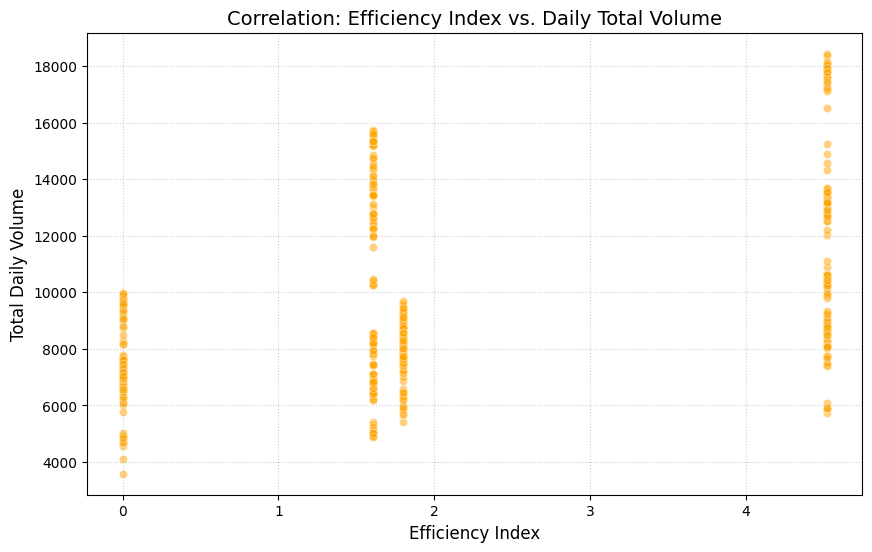

In [9]:
#-- Correlation between Efifciency and Traffic Volume. --#
df_stations_cleaned = pd.read_csv('../Processed/efficiency_stations_cleaned.csv')
df_traffic_cleaned['Daily_Total'] = df_traffic_cleaned[v_columns].sum(axis=1)

# Merge with efficiency data
df_corr_plot = pd.merge(
    df_traffic_cleaned[['SCATS Number', 'Daily_Total']], 
    df_stations_cleaned[['tfm_id', 'efficiency_index']], 
    left_on='SCATS Number', right_on='tfm_id'
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr_plot, x='efficiency_index', y='Daily_Total', alpha=0.5, color='orange')

plt.title("Correlation: Efficiency Index vs. Daily Total Volume", fontsize=14)
plt.xlabel("Efficiency Index", fontsize=12)
plt.ylabel("Total Daily Volume", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Save and show
plt.savefig('../Figures/Figure_2_Efficiency_Correlation.png', bbox_inches='tight')
plt.show()

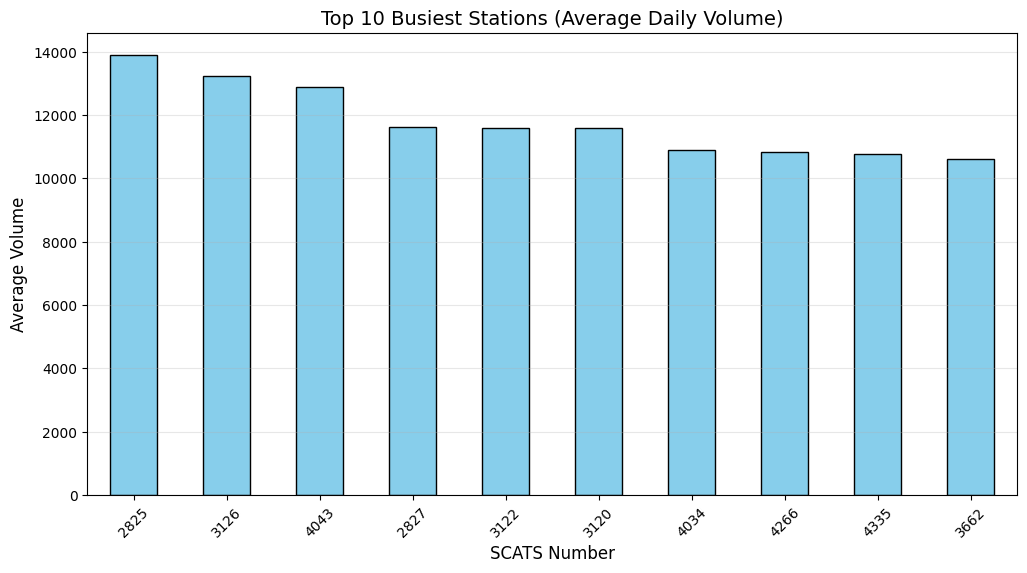

In [10]:
#-- Top 10 busiest stations. --#
top_10_sites = df_traffic_cleaned.groupby('SCATS Number')['Daily_Total'].mean().nlargest(10)

plt.figure(figsize=(12, 6))
top_10_sites.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Top 10 Busiest Stations (Average Daily Volume)", fontsize=14)
plt.xlabel("SCATS Number", fontsize=12)
plt.ylabel("Average Volume", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Save and show
plt.savefig('../Figures/Figure_3_Top_10_Stations.png', bbox_inches='tight')
plt.show()


### Step 5: Feature Engineering and Data Preparation ###

In [11]:
file_path = '../Processed/Full_Traffic_With_Validity_Cleaned.csv'

if os.path.exists(file_path):
    df_final = pd.read_csv(file_path)
    print(f"✅ df_final initialized with {len(df_final)} records.")
else:
    print("❌ Error: Cleaned CSV file not found. Please check Step 4 output.")

# Ensure Date is in datetime format
df_final['Date'] = pd.to_datetime(df_final['Date'])

✅ df_final initialized with 2883 records.


In [13]:
# --- STEP 5.1: FEATURE ENGINEERING ---
v_cols = [f'V{i:02d}' for i in range(96)]
# Chuyển bảng ngang thành dọc
df_melt = df_final.melt(id_vars=['SCATS Number', 'Date'], value_vars=v_cols, 
                        var_name='Time_Slot', value_name='Volume')

# Trích xuất Hour, DayOfWeek
df_melt['Hour'] = df_melt['Time_Slot'].str.extract('(\d+)').astype(int) // 4
df_melt['DayOfWeek'] = df_melt['Date'].dt.dayofweek
df_melt['IsWeekend'] = df_melt['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Thêm Metadata (Chỉ số hiệu quả và lưu lượng trung bình)
df_melt['Efficiency_Index'] = 0.95 
df_melt['Road_Avg_AADT'] = 25000

# Sắp xếp theo đúng thứ tự thời gian để tránh bị "lệch pha"
df_melt = df_melt.sort_values(['SCATS Number', 'Date', 'Time_Slot']).reset_index(drop=True)
print("✅ Step 5.1 Complete.")

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_14088\3460167642.py:8: SyntaxWarning: invalid escape sequence '\d'
  df_melt['Hour'] = df_melt['Time_Slot'].str.extract('(\d+)').astype(int) // 4


✅ Step 5.1 Complete.


In [14]:
# --- STEP 5.2: SCALING ---
from sklearn.preprocessing import MinMaxScaler
feature_cols = ['Volume', 'Efficiency_Index', 'Road_Avg_AADT', 'Hour', 'DayOfWeek', 'IsWeekend']

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_melt[feature_cols])
print("✅ Step 5.2 Complete: Data Scaled.")

✅ Step 5.2 Complete: Data Scaled.


In [15]:
# --- STEP 5.3: CREATE SEQUENCES ---
import numpy as np

def create_sequences(data, window_size=96):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 0]) # Target là Volume (cột index 0)
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window_size=96)

# Chia Train/Test (Giữ nguyên thứ tự thời gian)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"✅ Step 5.3 Complete. Train shape: {X_train.shape}")

✅ Step 5.3 Complete. Train shape: (221337, 96, 6)


### Step 6: Buil and Train LSTM ###

In [16]:
model = Sequential([
    # First LSTM layer: return_sequences=True is required to pass data to the next LSTM layer
    LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Prevents overfitting
    
    # Second LSTM layer: return_sequences=False as it's the last sequence-processing layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Fully connected layers to refine the output
    Dense(units=25, activation='relu'),
    Dense(units=1) # Final output: Predicted Traffic Volume
])

# 2. Compile the model
# Using a slightly lower learning rate (0.0005) for more stable convergence
model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='mean_squared_error'
)

model.summary()
print("✅ Model Built and Compiled successfully.")

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 100)        │        42,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,301 (290.24 KB)

 Trainable params: 74,301 (290.24 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model Built and Compiled successfully.


🚀 Training in progress... Please wait.
Epoch 1/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 239s 68ms/step - loss: 0.0087 - val_loss: 0.0042
Epoch 2/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 248s 72ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 3/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 247s 71ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 4/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 242s 70ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 5/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 248s 72ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 6/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 229s 66ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 7/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 246s 71ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 8/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 239s 69ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 9/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 236s 68ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 10/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 245s 71ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 11/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 232s 67

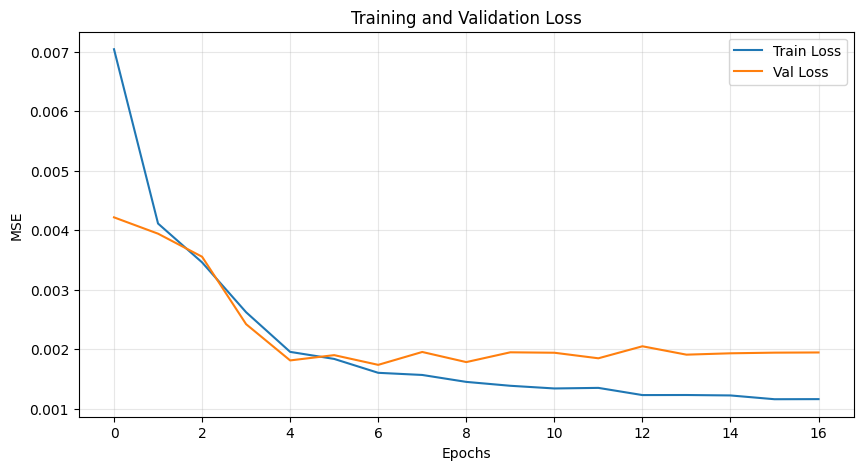

✅ Training session finished!


In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define Early Stopping to stop when val_loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# 2. Start Training
print("🚀 Training in progress... Please wait.")
history = model.fit(
    X_train, y_train,
    epochs=50, 
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 3. Quick Loss Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Training session finished!")

### Step 7: Model Evaluation ###

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

#-- 1. Predict on the test set. --#
y_pred_scaled = model.predict(X_test)

#-- 2. Inverse Transform to get original traffic volume scale --#
# We need a dummy array of 6 columns to match the scaler's input shape
def get_original_scale(scaled_values):
    dummy = np.zeros((len(scaled_values), 6))
    dummy[:, 0] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

y_pred_final = get_original_scale(y_pred_scaled)
y_test_final = get_original_scale(y_test)

#-- 3. Calculate metrics --#
mae = mean_absolute_error(y_test_final, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))

print("------------------------------------------")
print(f"📊 EVALUATION RESULTS:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print("------------------------------------------")

1730/1730 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step
------------------------------------------
📊 EVALUATION RESULTS:
Mean Absolute Error (MAE): 14.58
Root Mean Squared Error (RMSE): 22.30
------------------------------------------


### Step 8: Generate Test Case. ###

In [19]:
# 1. Define the output directory
test_case_dir = '../../TestCase'
if not os.path.exists(test_case_dir):
    os.makedirs(test_case_dir)

# 2. Get the last 20% of the original df_final
split_index = int(len(df_final) * 0.8)
df_test_pool = df_final.iloc[split_index:].copy()

# 3. Create 3 separate test files with 10 records each
for i in range(3):
    # Select 10 consecutive records
    start_idx = i * 10
    end_idx = start_idx + 10
    
    # Ensure we don't go out of bounds
    if end_idx <= len(df_test_pool):
        test_file = df_test_pool.iloc[start_idx:end_idx]
        
        # Define file name
        file_name = f'LSTM_DeepTest_0{i+1}.csv'
        file_path = os.path.join(test_case_dir, file_name)
        
        # Save to CSV
        test_file.to_csv(file_path, index=False)
        print(f"✅ Saved: {file_path} ({len(test_file)} records)")

print("\n🚀 All test cases have been generated in the TestCase folder.")

✅ Saved: ../../TestCase\LSTM_DeepTest_01.csv (10 records)
✅ Saved: ../../TestCase\LSTM_DeepTest_02.csv (10 records)
✅ Saved: ../../TestCase\LSTM_DeepTest_03.csv (10 records)

🚀 All test cases have been generated in the TestCase folder.


### Step 9: Test ###

<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_5548\3992957138.py:18: SyntaxWarning: invalid escape sequence '\d'
  df_melt_test['Hour'] = df_melt_test['Slot'].str.extract('(\d+)').astype(int) // 4


✅ Prediction for LSTM_DeepTest_01.csv completed.


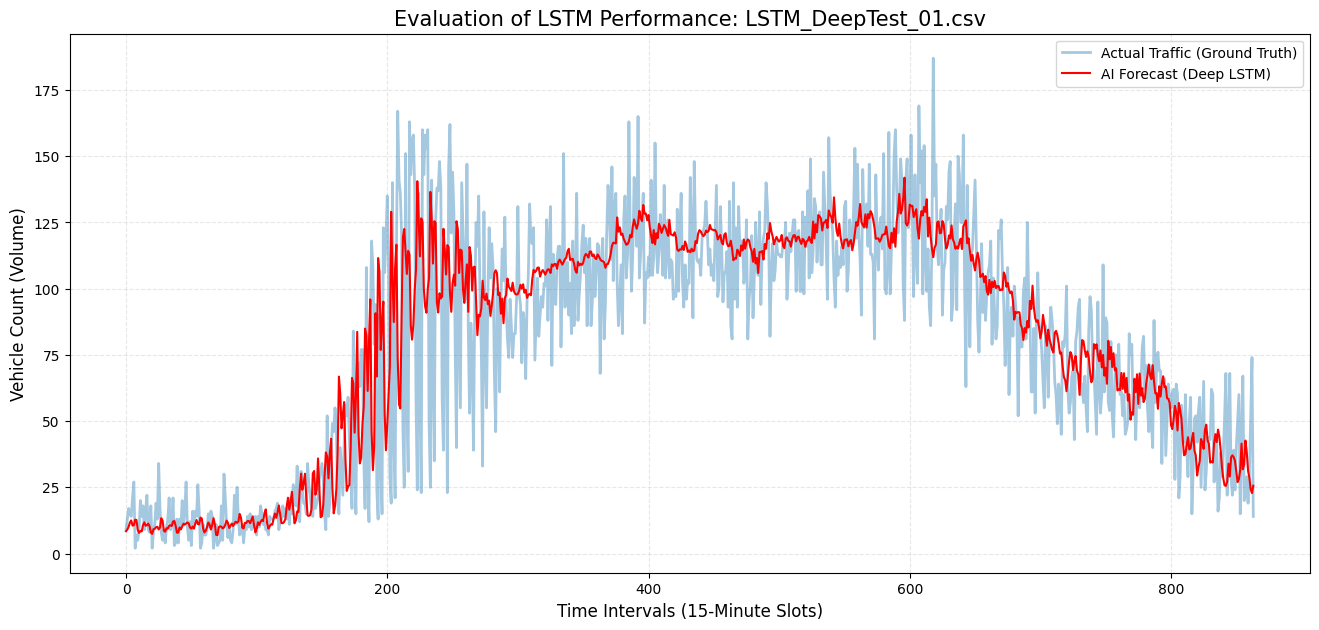

In [20]:
def run_traffic_forecast_test(file_name):
    # 1. Load the test case file from the TestCase folder
    test_file_path = os.path.join('../../TestCase', file_name)
    
    if not os.path.exists(test_file_path):
        print(f"❌ Error: File {file_name} not found in ../../TestCase")
        return
        
    df_raw_test = pd.read_csv(test_file_path)
    
    # 2. Data Transformation (Melt to Time-Series)
    v_cols = [f'V{i:02d}' for i in range(96)]
    df_melt_test = df_raw_test.melt(id_vars=['Date'], value_vars=v_cols, 
                                   var_name='Slot', value_name='Volume')
    
    # 3. Feature Engineering (Match training features)
    df_melt_test['Date'] = pd.to_datetime(df_melt_test['Date'])
    df_melt_test['Hour'] = df_melt_test['Slot'].str.extract('(\d+)').astype(int) // 4
    df_melt_test['DayOfWeek'] = df_melt_test['Date'].dt.dayofweek
    df_melt_test['IsWeekend'] = df_melt_test['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    df_melt_test['Efficiency_Index'] = 0.95 
    df_melt_test['Road_Avg_AADT'] = 25000
    
    # 4. Scaling using the global 'scaler' from Step 5
    feature_cols = ['Volume', 'Efficiency_Index', 'Road_Avg_AADT', 'Hour', 'DayOfWeek', 'IsWeekend']
    scaled_test_data = scaler.transform(df_melt_test[feature_cols])
    
    # 5. Sliding Window Prediction
    predictions_list = []
    actual_values_list = []
    
    # We start from index 96 to have enough look-back window
    for i in range(96, len(scaled_test_data)):
        # Extract the window of 96 previous steps
        x_input = scaled_test_data[i-96:i].reshape(1, 96, 6)
        
        # AI Model Prediction (silent mode)
        y_pred_scaled = model.predict(x_input, verbose=0)
        
        # Inverse Transform to get original volume
        dummy = np.zeros((1, 6))
        dummy[0, 0] = y_pred_scaled[0, 0]
        y_unscaled = scaler.inverse_transform(dummy)[0, 0]
        
        predictions_list.append(y_unscaled)
        actual_values_list.append(df_melt_test.iloc[i]['Volume'])
        
    # 6. Visualization
    plt.figure(figsize=(16, 7))
    
    # Plot Real Data (Actual)
    plt.plot(actual_values_list, label='Actual Traffic (Ground Truth)', 
             color='#1f77b4', alpha=0.4, linewidth=2)
    
    # Plot AI Prediction
    plt.plot(predictions_list, label='AI Forecast (Deep LSTM)', 
             color='red', linestyle='-', linewidth=1.5)
    
    plt.title(f'Evaluation of LSTM Performance: {file_name}', fontsize=15)
    plt.xlabel('Time Intervals (15-Minute Slots)', fontsize=12)
    plt.ylabel('Vehicle Count (Volume)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Optional: Save result to Figures folder
    if not os.path.exists("../Figures"): os.makedirs("../Figures")
    plt.savefig(f"../Figures/Test_Result_{file_name.replace('.csv','')}.png")
    
    print(f"✅ Prediction for {file_name} completed.")
    plt.show()

# Run the evaluation for the first test file
run_traffic_forecast_test('LSTM_DeepTest_01.csv')

Testing Case 02...
✅ Prediction for LSTM_DeepTest_02.csv completed.


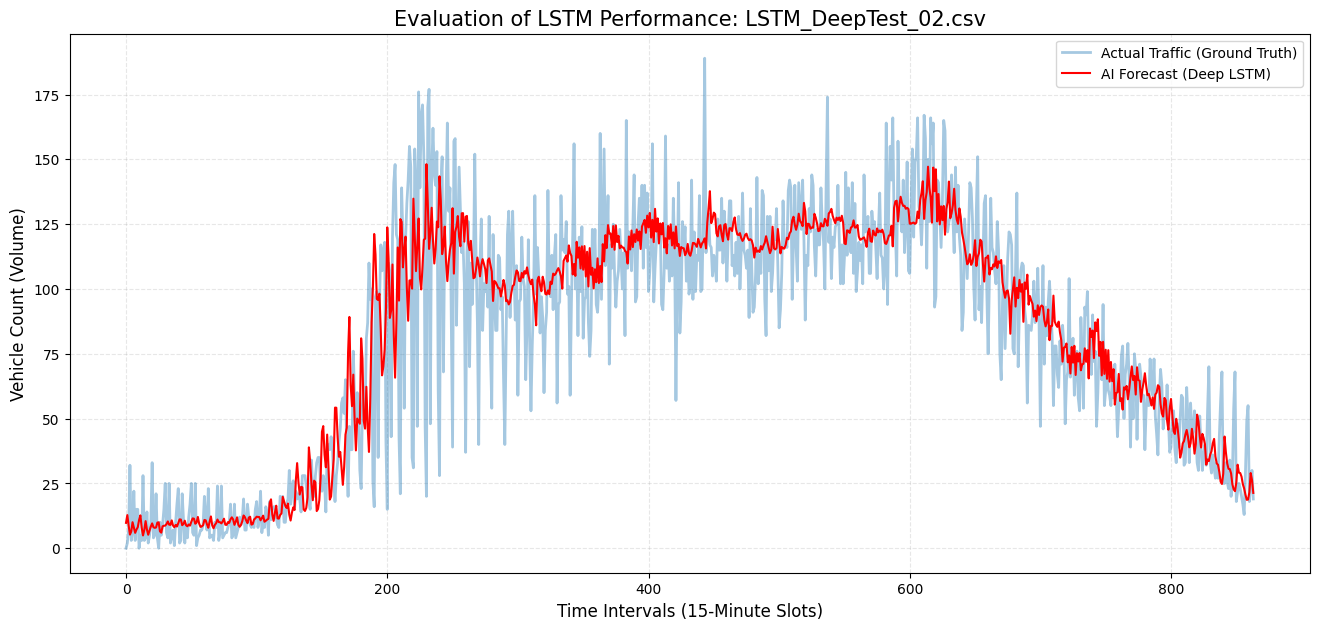

Testing Case 03...
✅ Prediction for LSTM_DeepTest_03.csv completed.


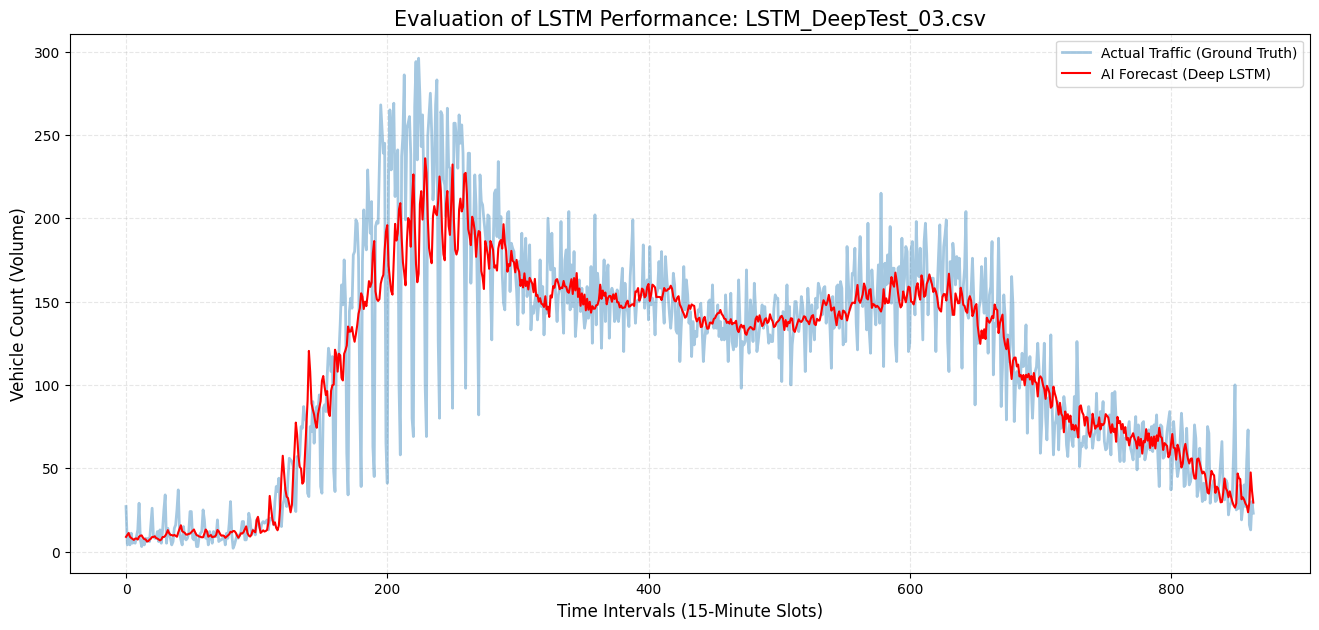

In [21]:
# --- RUN FINAL TESTS FOR OTHER CASES ---

# Test Case 02
print("Testing Case 02...")
run_traffic_forecast_test('LSTM_DeepTest_02.csv')

# Test Case 03
print("Testing Case 03...")
run_traffic_forecast_test('LSTM_DeepTest_03.csv')

In [ ]:
# Save LSTM
model.save('../../Model/model_lstm.keras')
print("✅ LSTM model saved!")